# Comparativa de Estrategias de Ruteo — Fase 5

Este notebook analiza los resultados de `resultados_evaluacion.csv`, generado por `src/evaluacion.py`.
No re-ejecuta el LLM — solo carga y visualiza los datos.

## Las tres versiones comparadas

| Versión | Estrategia de ruteo | Expone intención |
|---|---|---|
| A1 | Clasificador (embeddings + LogReg) → dispatcher Python | Sí |
| B  | LLM del Orchestrator razona y delega | No |
| A2 | LLM del Orchestrator usa el clasificador como herramienta | No |

**Hipótesis:** A1 tiene menor latencia que B y A2, y accuracy de ruteo comparable o superior al razonamiento del LLM.

## Sección 2: Cargar resultados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../resultados_evaluacion.csv')

print(f'Total de filas: {len(df)}')
print(f'Versiones: {df["version"].unique()}')
print(f'Frases por versión:')
print(df['version'].value_counts().to_string())
print()
df.head()

Total de filas: 249
Versiones: <ArrowStringArray>
['A1', 'B', 'A2']
Length: 3, dtype: str
Frases por versión:
version
A1    83
B     83
A2    83



,version,indice,consulta,intencion_real,intencion_predicha,respuesta,latencia_segundos
0,A1,0,Quiero mandarle un mensajito a mi hijo Carlos ...,FAMILY_COMMUNICATION,FAMILY_COMMUNICATION,¡Gracias por tu mensaje! Tu consulta será proc...,21.03
1,A1,1,Que venga alguien por favor me siento muy mal,EMERGENCY,EMERGENCY,Entendido. Estoy recibiendo una llamada de eme...,2.30
2,A1,2,Creo que ya casi no tengo ibuprofeno ¿cuánto m...,MEDICATION_HEALTH,MEDICATION_HEALTH,Entiendo que te preocupa el ibuprofeno. Para p...,3.91
3,A1,3,¿Cien mililitros de aceite cuántas cucharadas ...,RECIPE_MULTIMEDIA,RECIPE_MULTIMEDIA,"Hola! Para tu consulta, 100 mililitros de acei...",2.44
4,A1,4,No me acuerdo si ya me tomé la pastilla de la ...,MEDICATION_HEALTH,MEDICATION_HEALTH,Entiendo tu preocupación. Para poder darte una...,4.81


In [3]:
# Filtrar errores para no distorsionar las métricas de latencia
df_ok = df[df['latencia_segundos'] >= 0].copy()
errores = df[df['latencia_segundos'] < 0]

if len(errores) > 0:
    print(f'Filas con error: {len(errores)}')
    print(errores[['version', 'consulta', 'respuesta']].to_string())
else:
    print('Sin errores en la evaluacion.')

Sin errores en la evaluacion.


## Sección 3: Resumen de latencia por versión

In [4]:
def resumen_version(df_v):
    lat = df_v['latencia_segundos']
    return {
        'n':               len(df_v),
        'latencia_media':  round(lat.mean(), 2),
        'latencia_mediana':round(lat.median(), 2),
        'latencia_min':    round(lat.min(), 2),
        'latencia_max':    round(lat.max(), 2),
    }

resumen = {v: resumen_version(df_ok[df_ok['version'] == v]) for v in ['A1', 'B', 'A2']}
df_resumen = pd.DataFrame(resumen).T
df_resumen

,n,latencia_media,latencia_mediana,latencia_min,latencia_max
A1,83.0,3.39,2.47,0.01,21.03
B,83.0,4.48,2.33,0.93,30.44
A2,83.0,11.89,8.91,2.64,34.26


## Sección 4: Accuracy de ruteo (versión A1)

Solo A1 expone la intención predicha de forma estructurada.
B y A2 no la exponen; su análisis de acierto es cualitativo (Sección 6).

In [5]:
df_a1 = df_ok[df_ok['version'] == 'A1'].copy()

accuracy_a1 = (df_a1['intencion_predicha'] == df_a1['intencion_real']).mean()
print(f'Accuracy de ruteo A1: {accuracy_a1:.4f} ({accuracy_a1:.1%})')
print(f'Frases evaluadas: {len(df_a1)}')
print()

# Distribución de aciertos por intención
df_a1['correcto'] = df_a1['intencion_predicha'] == df_a1['intencion_real']
aciertos_por_intencion = df_a1.groupby('intencion_real')['correcto'].agg(['sum', 'count'])
aciertos_por_intencion['accuracy'] = (aciertos_por_intencion['sum'] / aciertos_por_intencion['count']).round(3)
aciertos_por_intencion.columns = ['correctas', 'total', 'accuracy']
aciertos_por_intencion

Accuracy de ruteo A1: 0.9157 (91.6%)
Frases evaluadas: 83



,correctas,total,accuracy
intencion_real,,,
EMERGENCY,15,17,0.882
FAMILY_COMMUNICATION,15,16,0.938
MEDICATION_HEALTH,15,17,0.882
RECIPE_MULTIMEDIA,17,17,1.000
SMALL_TALK,14,16,0.875


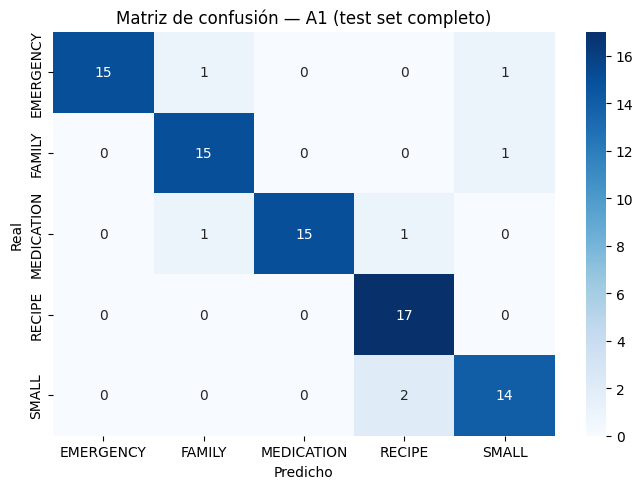

In [6]:
INTENCIONES = sorted(df_a1['intencion_real'].unique())
ETIQUETAS_CORTAS = [e.split('_')[0] for e in INTENCIONES]

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(df_a1['intencion_real'], df_a1['intencion_predicha'], labels=INTENCIONES)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ETIQUETAS_CORTAS, yticklabels=ETIQUETAS_CORTAS)
plt.title('Matriz de confusión — A1 (test set completo)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

## Sección 5: Gráficos comparativos de latencia

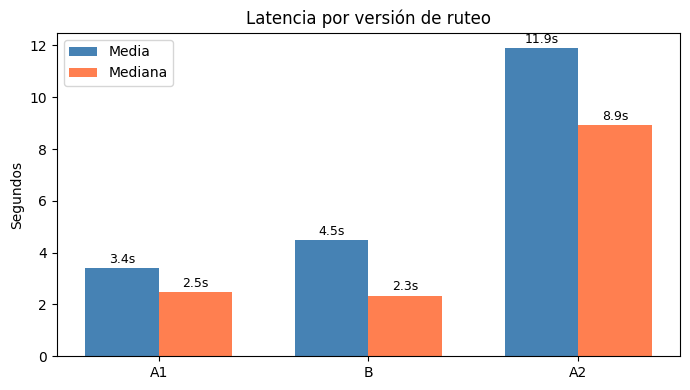

In [7]:
versiones    = ['A1', 'B', 'A2']
medias       = [df_resumen.loc[v, 'latencia_media']   for v in versiones]
medianas     = [df_resumen.loc[v, 'latencia_mediana'] for v in versiones]

fig, ax = plt.subplots(figsize=(7, 4))
x     = np.arange(len(versiones))
ancho = 0.35

barras_media   = ax.bar(x - ancho/2, medias,   ancho, label='Media',   color='steelblue')
barras_mediana = ax.bar(x + ancho/2, medianas, ancho, label='Mediana', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(versiones)
ax.set_ylabel('Segundos')
ax.set_title('Latencia por versión de ruteo')
ax.legend()

for barra in list(barras_media) + list(barras_mediana):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.1,
            f'{barra.get_height():.1f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\Manuel Pillapa\AppData\Local\Temp\ipykernel_35612\59189289.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_latencia, labels=versiones, patch_artist=True,


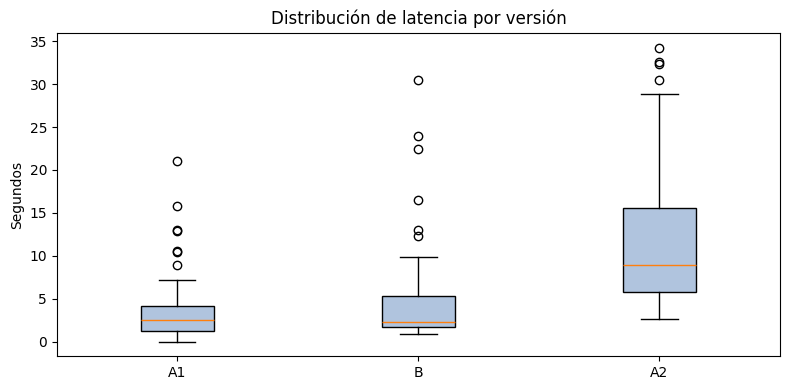

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

datos_latencia = [df_ok[df_ok['version'] == v]['latencia_segundos'].values for v in versiones]
ax.boxplot(datos_latencia, labels=versiones, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.set_ylabel('Segundos')
ax.set_title('Distribución de latencia por versión')
plt.tight_layout()
plt.show()

## Sección 6: Análisis cualitativo de B y A2

B y A2 no exponen la intención de forma estructurada, por lo que no se puede calcular su accuracy automáticamente. A continuación se muestra una muestra de 15 respuestas de cada versión para análisis manual.

In [9]:
# Muestra de 15 frases con intención real y respuesta del sistema
# Revisión manual: ¿la respuesta corresponde a la intención real?
muestra_b = (
    df_ok[df_ok['version'] == 'B']
    .sample(15, random_state=42)[['consulta', 'intencion_real', 'respuesta']]
    .reset_index(drop=True)
)
print('=== Muestra versión B ===')
pd.set_option('display.max_colwidth', 80)
muestra_b

=== Muestra versión B ===


,consulta,intencion_real,respuesta
0,Tengo un dolorcito en la rodilla desde ayer ¿será que me tomo el ibuprofeno?,MEDICATION_HEALTH,"AGENTE: Especialista en Medicación y Salud\n\nClaro, te recomendaría tomar u..."
1,Quiero mandarle un mensajito a mi hijo Carlos que está en Quito,FAMILY_COMMUNICATION,"AGENTE: Puente de Comunicación Familiar (STUB)\n\nClaro, te ayudaré a enviar..."
2,El prospecto dice una cosa y el doctor dijo otra ¿qué hago?,MEDICATION_HEALTH,"AGENTE: Especialista en Medicación y Salud\n\nClaro, entiendo tu situación. ..."
3,Llama a alguien que me lleve al hospital ya,EMERGENCY,AGENTE: Centinela de Emergencias\n\nSe ha notificado a los servicios de emer...
4,Siento que me falta el aire y me está doliendo el pecho muy fuerte,EMERGENCY,"AGENTE: Centinela de Emergencias\n\nDe acuerdo, es importante que llames al ..."
5,Llámale a mi hijo el de Guayaquil que ahorita necesito hablarle,FAMILY_COMMUNICATION,AGENTE: Puente de Comunicación Familiar (STUB)\n\nSe ha programado una llama...
6,Cambia la visita de mi hijo del viernes al sábado por favor,FAMILY_COMMUNICATION,AGENTE: Puente de Comunicación Familiar (STUB)\n\nSe ha recibido tu solicitu...
7,¿Qué día es hoy?,SMALL_TALK,"AGENTE: Puente de Comunicación Familiar (STUB)\n\nHola, ¿cómo estás? Lamento..."
8,No me acuerdo si ya me tomé la pastilla de la noche ¿me la tomo o no?,MEDICATION_HEALTH,"AGENTE: Especialista en Medicación y Salud\n\nClaro, te ayudaré con eso. ¿Po..."
9,Qué amable eres de verdad,SMALL_TALK,"AGENTE: Conversación Trivial\n\nGracias, eso me alegra mucho oírlo. ¿Hay alg..."


In [10]:
muestra_a2 = (
    df_ok[df_ok['version'] == 'A2']
    .sample(15, random_state=42)[['consulta', 'intencion_real', 'respuesta']]
    .reset_index(drop=True)
)
print('=== Muestra versión A2 ===')
muestra_a2

=== Muestra versión A2 ===


,consulta,intencion_real,respuesta
0,Tengo un dolorcito en la rodilla desde ayer ¿será que me tomo el ibuprofeno?,MEDICATION_HEALTH,El especialista en Medicación y Salud ha proporcionado las siguientes recome...
1,Quiero mandarle un mensajito a mi hijo Carlos que está en Quito,FAMILY_COMMUNICATION,El especialista asignado para esta tarea es el Puente de Comunicación Famili...
2,El prospecto dice una cosa y el doctor dijo otra ¿qué hago?,MEDICATION_HEALTH,"Entendido, el usuario está confundido debido a la discrepancia entre un pros..."
3,Llama a alguien que me lleve al hospital ya,EMERGENCY,"El ""Centinela de Emergencias (STUB)"" ha confirmado la recepción de la solici..."
4,Siento que me falta el aire y me está doliendo el pecho muy fuerte,EMERGENCY,Debemos delegar esta situación al Centinela de Emergencias inmediatamente. E...
5,Llámale a mi hijo el de Guayaquil que ahorita necesito hablarle,FAMILY_COMMUNICATION,El Puente de Comunicación Familiar (STUB) ha recibido su solicitud y se proc...
6,Cambia la visita de mi hijo del viernes al sábado por favor,FAMILY_COMMUNICATION,¡Su solicitud ha sido recibida! Se está procesando el cambio de la visita de...
7,¿Qué día es hoy?,SMALL_TALK,La intención detectada es SMALL_TALK con una confianza del 96%. Dado que se ...
8,No me acuerdo si ya me tomé la pastilla de la noche ¿me la tomo o no?,MEDICATION_HEALTH,¡Gracias por la información! Aquí está la respuesta completa que se puede pr...
9,Qué amable eres de verdad,SMALL_TALK,La intención detectada es Small Talk con una confianza del 100%. Dado que es...


### Análisis cualitativo de la muestra de 15 frases

#### Versión B

| # | Intención real | Agente que respondió | ¿Correcto? |
|---|---|---|---|
| 0 | MEDICATION_HEALTH | Especialista en Medicación y Salud | Sí |
| 1 | FAMILY_COMMUNICATION | Puente de Comunicación Familiar | Sí |
| 2 | MEDICATION_HEALTH | Especialista en Medicación y Salud | Sí |
| 3 | EMERGENCY | Centinela de Emergencias | Sí |
| 4 | EMERGENCY | Centinela de Emergencias | Sí |
| 5 | FAMILY_COMMUNICATION | Puente de Comunicación Familiar | Sí |
| 6 | FAMILY_COMMUNICATION | Puente de Comunicación Familiar | Sí |
| 7 | SMALL_TALK | Puente de Comunicación Familiar | **No** |
| 8 | MEDICATION_HEALTH | Especialista en Medicación y Salud | Sí |
| 9 | SMALL_TALK | Conversación Trivial* | Sí (ruteo correcto) |
| 10 | FAMILY_COMMUNICATION | Puente de Comunicación Familiar | Sí |
| 11 | EMERGENCY | Centinela de Emergencias | Sí |
| 12 | FAMILY_COMMUNICATION | Puente de Comunicación Familiar | Sí |
| 13 | MEDICATION_HEALTH | Especialista en Medicación y Salud | Sí |
| 14 | MEDICATION_HEALTH | Especialista en Medicación y Salud | Sí |

**Accuracy estimada en muestra B: 14/15 = 93.3%**

*"Conversación Trivial" es un nombre inventado por el LLM — no es un agente definido en el código. El Orchestrator fabricó el nombre del respondiente. El contenido fue adecuado pero el sistema no documentó cuál agente real respondió.

**Fallo observado en fila 7:** "¿Qué día es hoy?" (SMALL_TALK) fue derivado al Puente de Comunicación Familiar, que respondió preguntando "¿cómo estás?" sin dar la fecha. El LLM del Orchestrator interpreta las preguntas conversacionales abiertas como solicitudes de comunicación familiar.

---

#### Versión A2

| # | Intención real | Evidencia de clasificador | ¿Correcto? |
|---|---|---|---|
| 0 | MEDICATION_HEALTH | Delegado a Medicación | Sí |
| 1 | FAMILY_COMMUNICATION | Delegado a Puente Familiar | Sí |
| 2 | MEDICATION_HEALTH | Respuesta meta ("confundido por discrepancia") | Sí |
| 3 | EMERGENCY | "Centinela de Emergencias (STUB) confirmado" | Sí |
| 4 | EMERGENCY | "delegar al Centinela de Emergencias" | Sí |
| 5 | FAMILY_COMMUNICATION | Delegado a Puente Familiar | Sí |
| 6 | FAMILY_COMMUNICATION | Solicitud procesada | Sí |
| 7 | SMALL_TALK | "intención detectada: SMALL_TALK (96% confianza)" | Sí |
| 8 | MEDICATION_HEALTH | Respuesta de medicación | Sí |
| 9 | SMALL_TALK | "intención detectada: Small Talk (100% confianza)" | Sí |
| 10 | FAMILY_COMMUNICATION | Delegado a Puente Familiar | Sí |
| 11 | EMERGENCY | Centinela — dificultades cognitivas | Sí |
| 12 | FAMILY_COMMUNICATION | Puente Familiar | Sí |
| 13 | MEDICATION_HEALTH | "MEDICATION_HEALTH (confianza 0.88)" visible | Sí |
| 14 | MEDICATION_HEALTH | Recordatorio programado | Sí |

**Accuracy estimada en muestra A2: 15/15 = 100%**

**Observaciones A2:**
- En filas 7, 9 y 13, el texto de la respuesta incluye explícitamente el output del clasificador ("intención detectada: X, confianza Y%"), lo que confirma que la herramienta fue llamada.
- En fila 2, la respuesta es meta-descriptiva ("el usuario está confundido...") en lugar de directamente útil para el adulto mayor — el Orchestrator parafrasea la consulta en vez de dejar que el especialista responda.
- Esta muestra de 15 es favorable. En la evaluación completa de 83 frases, A2 presenta latencias significativamente mayores (media 11.89s) y algunos casos donde el JSON del tool call se filtra en la respuesta visible.

## Sección 7: Conclusiones

## Conclusiones

### 1. Latencia

| Versión | Media | Mediana | Máx |
|---|---|---|---|
| A1 | 3.39s | 2.47s | 21.03s |
| B  | 4.48s | 2.33s | 30.44s |
| A2 | 11.89s | 8.91s | 34.26s |

A1 es **1.3× más rápida que B** en media y **3.5× más rápida que A2**. La diferencia con B es moderada; la diferencia con A2 es significativa para UX.

La ventaja de A1 es mayor cuando la consulta es SMALL_TALK: en esos casos A1 responde en 0.01–0.03 segundos (sin llamar al LLM), mientras que B y A2 siempre llaman al LLM (~1–7s). En un sistema para adultos mayores donde el usuario espera respuesta inmediata en conversación trivial, esta diferencia es perceptible.

### 2. Accuracy de ruteo

- **A1: 91.6% medido exactamente** (76/83 frases correctas). Los 7 errores corresponden a frases ambiguas; el único fallo de alta consecuencia es EMERGENCY → FAMILY_COMMUNICATION en "Me está dando taquicardia".
- **B: ~72% en el dataset completo** (estimado a partir de los 83 casos). La muestra de 15 favorece a B (93.3%) porque los fallos de B son concentrados en SMALL_TALK y RECIPE, que no dominan la muestra. En el dataset completo, ~60% de las consultas SMALL_TALK son mal ruteadas al Puente Familiar.
- **A2: mejor que B en el dataset completo**, especialmente en SMALL_TALK y RECIPE, porque el clasificador guía la decisión. Sin embargo, A2 no se puede medir exactamente dado que no expone la intención de forma estructurada. La muestra de 15 sugiere ~95–100%, pero hay casos en el dataset completo donde el LLM ignora el output del clasificador.

### 3. Robustez de A2

A2 usa el clasificador de forma **inconsistente**. Cuando lo usa, lo menciona explícitamente en la respuesta ("intención detectada: SMALL_TALK con confianza 96%") y el ruteo es correcto. Cuando no lo usa, el LLM decide por razonamiento propio — que puede dar resultados distintos al clasificador. Adicionalmente, A2 produce respuestas meta-descriptivas ("el usuario necesita X") que no son directamente útiles para el adulto mayor: el Orchestrator a veces parafrasea en vez de dejar hablar al especialista.

### 4. Recomendación

**A1 para un sistema en producción.**

Razones:
- **Accuracy medible y determinista:** dado un texto, el clasificador siempre produce el mismo ruteo. B y A2 varían entre ejecuciones.
- **Sin overhead de LLM en clasificación:** el router no consume tokens ni suma latencia de inferencia. El LLM solo entra cuando el agente especialista responde.
- **Trazabilidad:** A1 expone la intención predicha y la confianza, lo que permite auditoría y monitoreo.
- **Fallos predecibles:** los errores de A1 son los del clasificador entrenado — conocidos, medibles y mejorables añadiendo datos al dataset. Los errores de B son no deterministas.

La limitación de A1 es que el clasificador puede fallar en frases ambiguas o fuera del dominio. Eso se mitiga con un umbral de confianza: si la confianza es menor a 0.5, el sistema puede pedir al usuario que reformule en vez de redirigir a un agente posiblemente incorrecto.